In [6]:
import matplotlib.pyplot as plt

In [1]:
import numpy as np
from scipy.spatial.distance import cdist

def filter_close_points(points, threshold, sort_method="lex"):
    """
    Filter points that are too close to each other, keeping only the barycenter of each cluster.
    The final list can be sorted either lexicographically (X then Y) or by shortest path.

    Args:
        points: numpy.ndarray, shape (N, 2), the list of 2D points.
        threshold: float, the maximum distance for two points to be considered "too close".
        sort_method: str, either "lex" (default) or "path".

    Returns:
        numpy.ndarray, shape (M, 2), the filtered and sorted list of points (barycenters).
    """
    if len(points) == 0:
        return np.array([])

    # Compute pairwise distances
    distances = cdist(points, points, 'euclidean')

    # Initialize a list to keep track of visited points
    visited = [False] * len(points)
    filtered_points = []

    for i in range(len(points)):
        if not visited[i]:
            # Find all points within the threshold distance of points[i]
            close_indices = np.where(distances[i] <= threshold)[0]
            cluster = points[close_indices]

            # Mark all points in the cluster as visited
            for idx in close_indices:
                visited[idx] = True

            # Compute the barycenter of the cluster
            barycenter = np.mean(cluster, axis=0)
            filtered_points.append(barycenter)

    # Convert to numpy array
    filtered_points = np.array(filtered_points)

    # Sort based on the chosen method
    if sort_method == "lex":
        # Sort by X, then by Y
        filtered_points = filtered_points[np.lexsort((filtered_points[:, 1], filtered_points[:, 0]))]
    elif sort_method == "path":
        # Sort by shortest path starting from the lowest and leftmost point
        filtered_points = filtered_points[np.lexsort((filtered_points[:, 1], filtered_points[:, 0]))]
        path = [filtered_points[0]]
        remaining_points = filtered_points[1:]

        while len(remaining_points) > 0:
            last_point = path[-1]
            dists = np.linalg.norm(remaining_points - last_point, axis=1)
            next_idx = np.argmin(dists)
            path.append(remaining_points[next_idx])
            remaining_points = np.delete(remaining_points, next_idx, axis=0)

        filtered_points = np.array(path)
    else:
        raise ValueError("sort_method must be either 'lex' or 'path'")

    return filtered_points


In [33]:
aaa= np.random.uniform(1.998,2.005,(50,2))
aaa

array([[2.00137519, 2.00393828],
       [2.0007985 , 1.99840375],
       [2.003566  , 1.99981373],
       [2.00277591, 2.00028891],
       [2.00341199, 1.99943506],
       [2.00422323, 2.00350315],
       [2.00083944, 2.00327998],
       [1.99984878, 2.00230665],
       [2.00246709, 2.0035257 ],
       [2.00433405, 2.00335961],
       [2.00044327, 1.99858718],
       [2.00334537, 2.00200291],
       [1.99955772, 2.00090886],
       [2.00200727, 1.99963492],
       [1.99816854, 2.0015132 ],
       [2.00080219, 2.0047303 ],
       [2.00088463, 2.00181352],
       [2.00021554, 2.00399812],
       [2.00452258, 2.00111873],
       [2.00185757, 1.99938503],
       [2.00132382, 1.99856816],
       [2.00092921, 2.00395714],
       [2.00332653, 2.00009063],
       [2.00122358, 1.99802149],
       [2.00268676, 1.99960744],
       [2.00090642, 2.00018044],
       [1.99880118, 2.00028883],
       [2.00125051, 2.00355703],
       [2.00269403, 1.9997245 ],
       [2.00090846, 2.00447765],
       [2.

In [44]:
bbb = filter_close_points(aaa, .00000000000005, sort_method="lex")

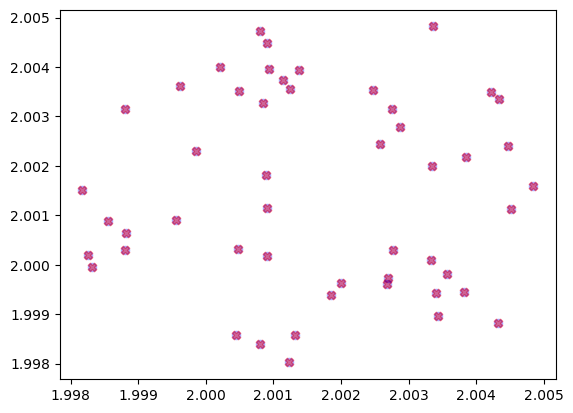

In [45]:
fig, ax=plt.subplots()
ax.plot(*aaa.T, 'ob', alpha=0.2)
ax.scatter(*bbb.T, marker='X', color='red', alpha=0.5)